In [ ]:
# Day 1 - Simple ML model

In [21]:
from sklearn import tree

# Step 1: Collect Data

# Features: [weight (grams), color (0 = red, 1 = orange)]

features = [

[150, 0], # Apple

[170, 0], # Apple

[130, 1], # Orange

[120, 1], # Orange

[160, 0], # Apple

[80, 0], # Orange

[200, 1]  # Apple

]

labels = ["apple", "apple", "orange", "orange", "apple", "orange", "apple"]

In [16]:

# Step 2: Train a model

clf = tree.DecisionTreeClassifier()

clf = clf.fit(features, labels)

In [17]:
# Step 3: Predict!

print(clf.predict([[160, 0]])) # Heavy and red-ish? Probably an apple!

print(clf.predict([[115, 1]])) # Light and orange? Probably an orange!

print(clf.predict([[190, 0]])) # Heavy and red-ish? Probably an apple! But it's heavier than any apple we trained on, so it might be an orange! Let's see what the model says.

print(clf.predict([[80, 0]])) # Light and red-ish? Probably an orange! But it's lighter than any orange we trained on, so it might be an apple! Let's see what the model says.

['apple']
['orange']
['apple']
['orange']


1.0


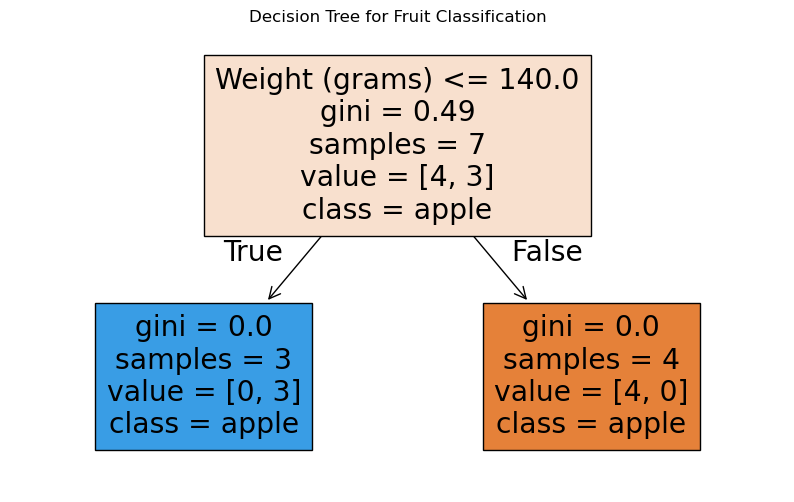

In [18]:
# check the accuracy of the model

print(clf.score(features, labels)) # 100% accuracy on our training data!

# visualize the decision tree with the actual labels and feature names

import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(10, 6))
tree.plot_tree(clf, filled=True, feature_names=["Weight (grams)", "Color (0=red, 1=orange)"], class_names=labels)
plt.title("Decision Tree for Fruit Classification")
plt.show()


In [19]:
# generate synthetic data for testing

import numpy as np
# Generate synthetic data for testing
np.random.seed(42)  # For reproducibility
synthetic_features = np.random.randint(100, 200, size=(10, 2))  # 10 samples, 2 features
synthetic_labels = np.random.choice(["apple", "orange"], size=10)  # Random labels
# Predict on synthetic data

predictions = clf.predict(synthetic_features)
print("Synthetic Features:\n", synthetic_features)
print("Predicted Labels:\n", predictions)



Synthetic Features:
 [[151 192]
 [114 171]
 [160 120]
 [182 186]
 [174 174]
 [187 199]
 [123 102]
 [121 152]
 [101 187]
 [129 137]]
Predicted Labels:
 ['apple' 'orange' 'apple' 'apple' 'apple' 'apple' 'orange' 'orange'
 'orange' 'orange']


Accuracy on synthetic data: 0.6


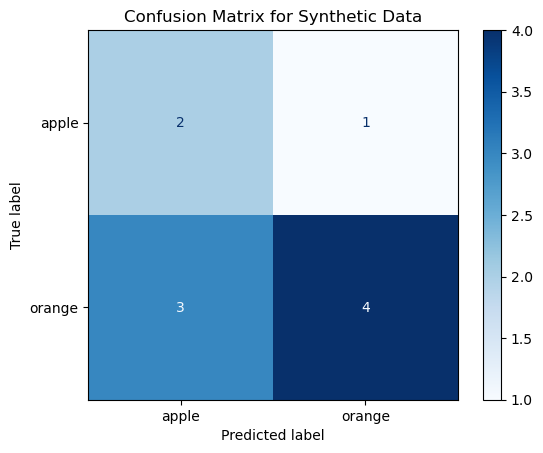

In [20]:
# checking accuracy on synthetic data (note: this is just for demonstration, as the labels are random)

accuracy = np.mean(predictions == synthetic_labels)
print("Accuracy on synthetic data:", accuracy)

# confusion matrix for synthetic data
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(synthetic_labels, predictions, labels=["apple", "orange"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["apple", "orange"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Synthetic Data")
plt.show()
